In [ ]:
import os, sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [24]:
REPO_URL = 'https://github.com/infi9itea/h-orb-vo'
REPO_NAME = 'h-orb-vo'

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}

%cd {REPO_NAME}

print("Setup done")

Cloning into 'h-orb-vo'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 90 (delta 40), reused 68 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 131.31 KiB | 470.00 KiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/h-orb-vo/h-orb-vo/h-orb-vo/h-orb-vo
Setup done


In [ ]:
from feature_tracker import FeatureTracker, TrackerConfig

In [25]:
trajectory = [np.array([0.0, 0.0])]

In [26]:
cfg = TrackerConfig(
    detector='harris',
    max_features=500,
    harris_min_distance=10,
    harris_threshold=0.01
)

In [27]:
tracker = FeatureTracker(cfg)

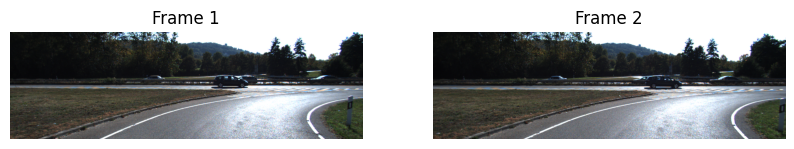

In [28]:
img1 = cv2.imread('/content/000000.png')
img2 = cv2.imread('/content/000001.png')

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Frame 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Frame 2")
plt.axis("off")

plt.show()

Detected corners: 106


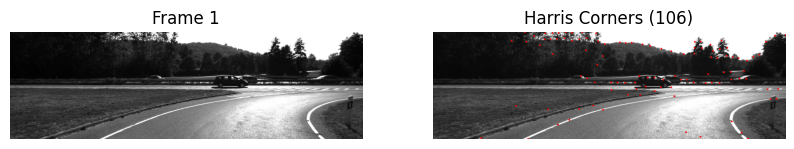

In [29]:
pts1 = tracker.detect(gray1)

print("Detected corners:", len(pts1))

corner_img = cv2.cvtColor(gray1, cv2.COLOR_GRAY2BGR)

for x, y in pts1:
    cv2.circle(corner_img, (int(x), int(y)), 3, (0, 0, 255), -1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray1, cmap='gray')
plt.title("Frame 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(corner_img, cv2.COLOR_BGR2RGB))
plt.title(f"Harris Corners ({len(pts1)})")
plt.axis("off")

plt.show()

In [30]:
pts1_t, pts2_t, _ = tracker.track(gray1, gray2, pts1)

print("Tracked features:", len(pts1_t))

Tracked features: 61


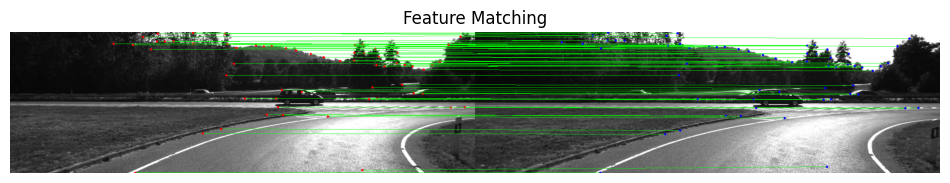

In [31]:
h, w = gray1.shape

canvas = np.hstack([
    cv2.cvtColor(gray1, cv2.COLOR_GRAY2BGR),
    cv2.cvtColor(gray2, cv2.COLOR_GRAY2BGR)
])

for i in range(min(200, len(pts1_t))):
    p1 = tuple(pts1_t[i].astype(int))
    p2 = tuple((pts2_t[i] + [w, 0]).astype(int))

    cv2.line(canvas, p1, p2, (0, 255, 0), 1)
    cv2.circle(canvas, p1, 3, (0, 0, 255), -1)
    cv2.circle(canvas, p2, 3, (255, 0, 0), -1)

plt.figure(figsize=(12,5))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title("Feature Matching")
plt.axis("off")
plt.show()


Motion Stats
Mean   : 33.742702
Median : 33.549755
Max    : 77.41969


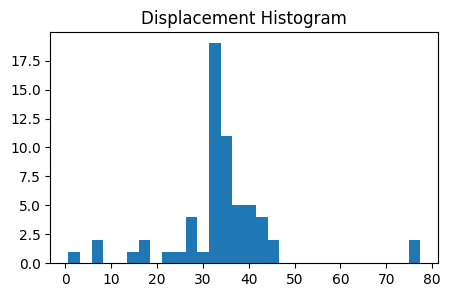

In [32]:
if len(pts1_t) > 0:
    diff = pts2_t - pts1_t
    dist = np.linalg.norm(diff, axis=1)

    print("\nMotion Stats")
    print("Mean   :", dist.mean())
    print("Median :", np.median(dist))
    print("Max    :", dist.max())

    plt.figure(figsize=(5,3))
    plt.hist(dist, bins=30)
    plt.title("Displacement Histogram")
    plt.show()
else:
    print("No tracked points found")

In [33]:
if len(pts1_t) > 0:
    motion = np.mean(pts2_t - pts1_t, axis=0)

    new_pos = trajectory[-1] + motion
    trajectory.append(new_pos)

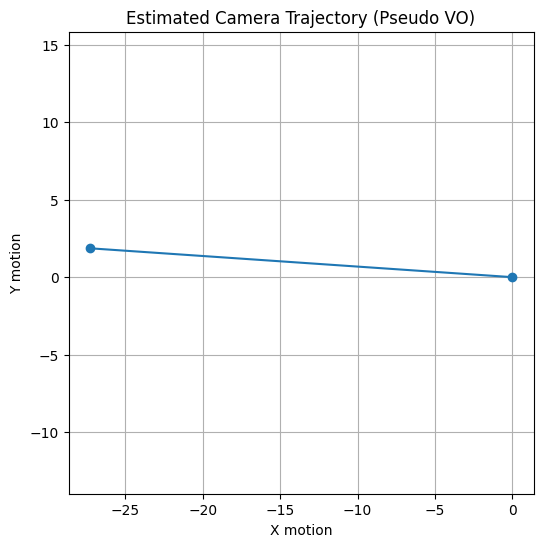

In [34]:
traj = np.array(trajectory)

plt.figure(figsize=(6,6))
plt.plot(traj[:, 0], traj[:, 1], marker='o')
plt.title("Estimated Camera Trajectory (Pseudo VO)")
plt.xlabel("X motion")
plt.ylabel("Y motion")
plt.grid(True)
plt.axis('equal')
plt.show()